In [87]:
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, classification_report


In [ ]:
df=pd.read_csv('data.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,84230200%,M,1799%,1038%,12280%,100100%,12%,28%,30%,15%,...,2538%,1733%,18460%,201900%,16%,67%,71%,27%,46%,12%
1,84251700%,M,2057%,1777%,13290%,132600%,8%,8%,9%,7%,...,2499%,2341%,15880%,195600%,12%,19%,24%,19%,28%,9%
2,8430090300%,M,1969%,2125%,13000%,120300%,11%,16%,20%,13%,...,2357%,2553%,15250%,170900%,14%,42%,45%,24%,36%,9%
3,8434830100%,M,1142%,2038%,7758%,38610%,14%,28%,24%,11%,...,1491%,2650%,9887%,56770%,21%,87%,69%,26%,66%,17%
4,8435840200%,M,2029%,1434%,13510%,129700%,10%,13%,20%,10%,...,2254%,1667%,15220%,157500%,14%,21%,40%,16%,24%,8%


In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df.shape

(569, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       569 non-null    object
 1   diagnosis                569 non-null    object
 2   radius_mean              569 non-null    object
 3   texture_mean             569 non-null    object
 4   perimeter_mean           569 non-null    object
 5   area_mean                569 non-null    object
 6   smoothness_mean          569 non-null    object
 7   compactness_mean         569 non-null    object
 8   concavity_mean           569 non-null    object
 9   concave points_mean      569 non-null    object
 10  symmetry_mean            569 non-null    object
 11  fractal_dimension_mean   569 non-null    object
 12  radius_se                569 non-null    object
 13  texture_se               569 non-null    object
 14  perimeter_se             569 non-null    o

In [ ]:
df.drop('id', axis=1, inplace=True)

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        # Remove % if present
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)

        # Convert to numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,1799,1038,12280,100100,12,28,30,15,24,...,2538,1733,18460,201900,16,67,71,27,46,12
1,1,2057,1777,13290,132600,8,8,9,7,18,...,2499,2341,15880,195600,12,19,24,19,28,9
2,1,1969,2125,13000,120300,11,16,20,13,21,...,2357,2553,15250,170900,14,42,45,24,36,9
3,1,1142,2038,7758,38610,14,28,24,11,26,...,1491,2650,9887,56770,21,87,69,26,66,17
4,1,2029,1434,13510,129700,10,13,20,10,18,...,2254,1667,15220,157500,14,21,40,16,24,8


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#Random Forest (no scaling needed)
rf_model = RandomForestClassifier(random_state=42)

In [ ]:
#SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])


In [ ]:
#XgBoost
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
#Training
rf_model.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
rf_pred = rf_model.predict(X_test)
svm_pred = svm_pipeline.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [ ]:
print("===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("\n===== SVM =====")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

print("\n===== XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

===== RANDOM FOREST =====
Accuracy: 0.9649122807017544
Recall: 0.9047619047619048
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


===== SVM =====
Accuracy: 0.9736842105263158
Recall: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


===== XGBOOST =====
Accuracy: 0.956140350877193
Recall: 0.8809523809523809
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
      

In [ ]:
print("RF Train:", rf_model.score(X_train, y_train))
print("RF Test:", rf_model.score(X_test, y_test))

RF Train: 1.0
RF Test: 0.9649122807017544


In [ ]:
print("SVM Train:", svm_pipeline.score(X_train, y_train))
print("SVM Test:", svm_pipeline.score(X_test, y_test))

RF Train: 0.9868131868131869
RF Test: 0.9736842105263158


In [ ]:
print("XGboost Train:", xgb_model.score(X_train, y_train))
print("XGboost Test:", xgb_model.score(X_test, y_test))

XGboost Train: 1.0
XGboost Test: 0.956140350877193


In [88]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='recall')

print("Recall CV:", scores)
print("Mean Recall:", scores.mean())

Recall CV: [0.97674419 0.86046512 0.92857143 1.         0.97619048]
Mean Recall: 0.9483942414174973


In [89]:
rf_cv = cross_val_score(rf_model, X, y, cv=cv, scoring='recall')
svm_cv = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='recall')
xgb_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='recall')

print("RF Recall:", rf_cv.mean())
print("SVM Recall:", svm_cv.mean())
print("XGB Recall:", xgb_cv.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

RF Recall: 0.9198228128460688
SVM Recall: 0.9483942414174973
XGB Recall: 0.9388704318936878


# **SVM is the best model**

Tree based algo. like random forest, xgboost, desicion tree they dont need scaling as they make desicion based on threshold not dist, only dist based model needs scaling (SVM, KNN, logistic reg)

for tree based algo

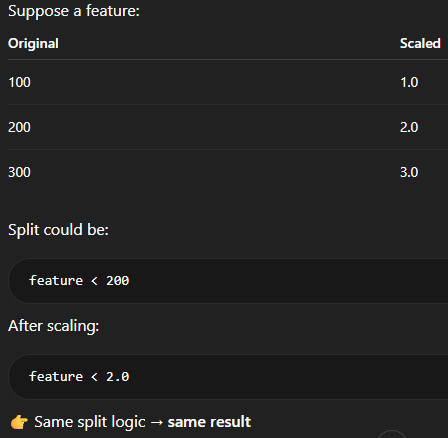

**Main Types of Cross-Validation**

1) Hold-Out Validation (Basic Split)

Split once (e.g., 80–20)

Not technically CV, but widely used

👉 Fast but less reliable

2) K-Fold Cross Validation

Data split into K parts (folds)

Train on K-1, test on 1 → repeat K times

👉 Most commonly used

3) Stratified K-Fold

Same as K-Fold BUT:

Maintains class balance in each fold

✔ Best for classification problems (like yours)

4) Leave-One-Out CV (LOOCV)
K = number of samples

Train on all except 1, test on that 1

👉 Very accurate but:

❌ Extremely slow

5) Leave-P-Out CV

Leave P samples out for testing

👉 Generalization of LOOCV

👉 Rarely used (computationally expensive)

6) Repeated K-Fold

Runs K-Fold multiple times with different splits

👉 More stable results

7) Time Series CV (Forward Chaining)

Used for time-based data

Example:

Train → [1,2,3] → Test → [4]

Train → [1,2,3,4] → Test → [5]

👉 No shuffling ❌

👉 Keeps time order

8) Group K-Fold

Ensures same group is not split across train/test

Example:

Patients, users, stores

👉 Avoids data leakage

# What Stratified K-Fold does

👉 It keeps same class ratio in every fold

So if original data is:

63% benign
37% malignant

Then every fold ≈ same ratio